# Week 3 - Dataset Selection and Final Project Planning Lab

**Author:** Katerina Smith

## Project Overview

This notebook selects and examines the dataset for the final course project. It covers the following:

1. Data Selection
2. Dataset Exploration
3. Data Quality Assessment
4. Project Planning

**How to use this notebook:** run every cell from top to bottom
(Runtime -> Restart session and run all in Colab).

## Setup and Environment

All libraries used come pre-installed in Google Colab. A fixed random seed is set so results are identical on every run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("pandas", pd.__version__)
print("numpy", np.__version__)

pandas 2.2.3
numpy 2.1.3


## 1. Data Selection

**Dataset:** Cervical Cancer (Risk Factors)

**Source:** UCI Machine Learning Repository
<https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors>

Hospital Universitario de Caracas, Caracas, Venezuela (2017). License: CC BY 4.0.

I selected this dataset because I have an interest in women's health and in using data to guide healthcare interventions when screening resources are limited. I am also interested in how exposures and behaviors can relate to a serious health outcome. The health problem that this topic addresses is how cervical cancer is oftentimes preventable through screening and early treatment, but screening capacity can be limited. This project relates to my professional goal of finding ways to predict adverse health outcomes where resources are limited but large datasets exist. It would also give me meaningful experience in building a full pipeline on a realistic problem with imperfect data.

The dataset meets all project requirements: it has a binary target (Biopsy), 858 observations (minimum 300), and 32 predictors (minimum 10).

## 2. Dataset Exploration

In [2]:
#import the data (local Colab session or through Github repo)

DATA_FILE = "risk_factors_cervical_cancer.csv"
DATA_URL = (
    "https://raw.githubusercontent.com/katerina-smith/Programming_for_HDS_Week3/"
    "main/risk_factors_cervical_cancer.csv"
)

source = DATA_FILE if Path(DATA_FILE).exists() else DATA_URL
df = pd.read_csv(source, na_values="?")
print("Loaded from:", source)
print("Shape:", df.shape)



Loaded from: https://raw.githubusercontent.com/katerina-smith/Programming_for_HDS_Week3/main/risk_factors_cervical_cancer.csv
Shape: (858, 36)


### Target variable and predictors

The target is Biopsy (1 = positive, 0 = negative). A biopsy is the confirmatory test for cervical cancer, so it is the most meaningful of the four outcome columns. The other three outcome columns (Hinselmann, Schiller, Citology) are screening tests that are strongly related to the biopsy results and are excluded from this analysis.

There are 32 predictors that fall into these groups: demographics (age), sexual and reproductive history (partners, age at first intercourse, pregnancies), smoking, contraception (hormonal contraceptives, IUD), STD history (overall and by type), and prior diagnoses (Dx columns). Most are counts, durations, or 0/1 (no/yes) indicators.

In [3]:
#check requirements
TARGET = "Biopsy"
#other screening test results
OTHER_TESTS = ["Hinselmann", "Schiller", "Citology"]
predictors = [c for c in df.columns if c != TARGET and c not in OTHER_TESTS]

print("Binary target:", sorted(df[TARGET].unique().tolist()))
print("Observations:", len(df), "(need at least 300)")
print("Predictors:", len(predictors), "(need at least 10)")

Binary target: [0, 1]
Observations: 858 (need at least 300)
Predictors: 32 (need at least 10)


### Explore dataset structure

In [4]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

### Identify target variable

In [6]:
counts = df[TARGET].value_counts().sort_index()
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)}))

print("\nCorrelation of the other test results with Biopsy:")
print(df[OTHER_TESTS + [TARGET]].corr()[TARGET].drop(TARGET).round(2))


        count  percent
Biopsy                
0         803     93.6
1          55      6.4

Correlation of the other test results with Biopsy:
Hinselmann    0.55
Schiller      0.73
Citology      0.33
Name: Biopsy, dtype: float64


### Descriptive statistics

In [7]:
df[predictors].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.82,8.50,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.53,1.67,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,17.00,2.80,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.28,1.45,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.15,0.35,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.22,4.09,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.45,2.23,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.64,0.48,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.26,3.76,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.11,0.32,0.0,0.0,0.0,0.0,1.0


In [8]:
#average of key predictors for biopsy-negative vs. biopsy-positive patients

key_cols = ["Age", "Number of sexual partners", "Num of pregnancies",
            "Hormonal Contraceptives (years)", "STDs (number)"]
df.groupby(TARGET)[key_cols].mean().round(2).T.rename(
    columns={0: "Biopsy negative", 1: "Biopsy positive"})

Biopsy,Biopsy negative,Biopsy positive
Age,26.70,28.64
Number of sexual partners,2.53,2.52
Num of pregnancies,2.26,2.54
Hormonal Contraceptives (years),2.17,3.32
STDs (number),0.16,0.38


## Exploratory Visualizations


Figure 1: Class balance of the target.

Only 55 of 858 patients (6.4%) have a positive biopsy, so the classes are strongly imbalanced.

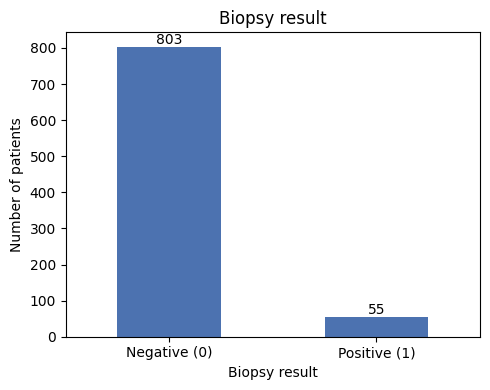

In [9]:
ax = df[TARGET].value_counts().sort_index().plot(kind="bar", color="#4C72B0", figsize=(5, 4))
ax.bar_label(ax.containers[0])
ax.set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
ax.set_xlabel("Biopsy result")
ax.set_ylabel("Number of patients")
ax.set_title("Biopsy result")
plt.tight_layout()
plt.show()

Figure 2: Biopsy-positive rate by risk factor.

Each pair of bars compares patients who do not have the factor (blue) with patients who do (red).

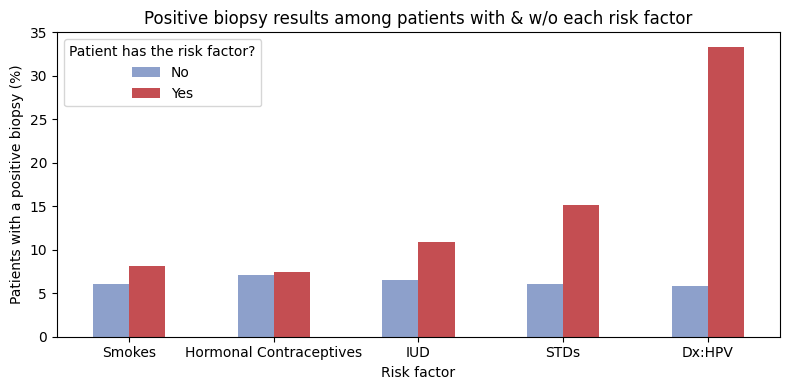

,No,Yes
Smokes,6.1,8.1
Hormonal Contraceptives,7.1,7.5
IUD,6.5,10.8
STDs,6.1,15.2
Dx:HPV,5.8,33.3


In [10]:
factors = ["Smokes", "Hormonal Contraceptives", "IUD", "STDs", "Dx:HPV"]
pct_positive = pd.DataFrame({f: df.groupby(f)[TARGET].mean() * 100 for f in factors}).T
pct_positive.columns = ["No", "Yes"]

ax = pct_positive.plot(kind="bar", color=["#8DA0CB", "#C44E52"], figsize=(8, 4))
ax.set_xticklabels(pct_positive.index, rotation=0)
ax.set_xlabel("Risk factor")
ax.set_ylabel("Patients with a positive biopsy (%)")
ax.set_title("Positive biopsy results among patients with & w/o each risk factor")
ax.legend(title="Patient has the risk factor?")
plt.tight_layout()
plt.show()

pct_positive.round(1)

## 3. Data Quality Assessment

### Explore missing values

In [11]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(1),
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)

print("Total missing cells:", int(df.isna().sum().sum()))
print("Rows with at least one missing value:", int(df.isna().any(axis=1).sum()), "of", len(df))
missing

Total missing cells: 3622
Rows with at least one missing value: 799 of 858


,missing,percent
STDs: Time since first diagnosis,787,91.7
STDs: Time since last diagnosis,787,91.7
IUD (years),117,13.6
IUD,117,13.6
Hormonal Contraceptives,108,12.6
Hormonal Contraceptives (years),108,12.6
STDs (number),105,12.2
STDs,105,12.2
STDs:vulvo-perineal condylomatosis,105,12.2
STDs:vaginal condylomatosis,105,12.2


### Explore other problematic data

In [12]:
#duplicate rows
print("\nDuplicate rows:", int(df.duplicated().sum()))

#impossible values: first intercourse at an age older than the patient's current age
impossible = df[df["First sexual intercourse"] > df["Age"]]
print("\nRows where age at first intercourse > current age:", len(impossible))
impossible[["Age", "First sexual intercourse"]]



Duplicate rows: 23

Rows where age at first intercourse > current age: 2


,Age,First sexual intercourse
312,23,27.0
812,14,16.0


### Findings:
- Missing values: 3,622 cells are missing, and 799 of 858 patients are missing at least one value. Patients could skip questions, so the missingness here is not random.
 - Nearly empty columns: "STDs: Time since first diagnosis" and "STDs: Time since last diagnosis" are about 92% missing. They are only filled in for patients with an STD diagnosis, so "missing" mostly means "not applicable."
- Duplicate rows: There are 23 duplicate rows.
- Impossible values: Two patients have a first-intercourse age that is later than their current age.

### Anticipate preprocessing
1. Drop the three other screening tests.
2. Drop the two nearly empty "time since diagnosis" columns. The yes/no “STDs” column already carries the useful information.
3. Set the two impossible values to missing.
4. Check the duplicate rows and remove exact duplicates before splitting the data.
5. Split into training and test sets first, then impute missing values using the training data only.
6. Scale continuous features for models that need it, and use class weights to handle the class imbalance.

### Potential challenges
- Very few positive cases: only 55 of 858 patients.
- Missing data: how to handle missing data and skipped answers.
- Single hospital and self-reported data: results may not generalize to other populations, and sensitive history of this dataset may be under-reported.



## 4. Project Planning

### Proposed prediction problem

Using a patient's age, sexual and reproductive history, contraceptive use, smoking, and STD history, predict whether their cervical biopsy will be positive. The practical use is risk stratification: to help a clinic decide which patients to prioritize for follow-up. This is only a decision-support tool and does not replace diagnostic testing.

### Target variable

Biopsy (binary): 1 = positive, 0 = negative. About 6.4% of patients are positive.

### Candidate evaluation metrics

Because only about 6% of patients have a positive biopsy, accuracy would be misleading (always predicting "negative" is 93.6% accurate but finds no cases). I plan to use:

- Average precision (PR-AUC) as the primary metric, because it works well when the positive class is rare.
- Confusion matrix, to show how many cases are found and missed.
